In [1]:
#imports 
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings 
import sharpy.sharpy_main  # used to run SHARPy from Jupyter

In [2]:
#conditions of operation
u_inf = 1.
alpha_deg = 2.  # Define angle of attack for static aeroelastic analysis.
rho = 1.02      # Air density.

In [3]:
#setting up our ROM method
c_ref = .125 #meters
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

#our discretization
M = 16             # Number of chordwise panels
N = 32             # Number of spanwise panels
M_star_fact = 10   # Length of the wake in chords.
num_modes =  8     # Number of vibration modes retained in the structural model.

In [4]:
#structure... 
#our starting point for the structure will be from assuming a base consisting of a 
#carbon fibre plate of dimension 3 X 750 x 95 mm with servo shown below of mass 28g along with a linear, the wing 
#itself will be rectangular with a chord of 125mm and a span of 750mm
#actuator of length 100mm with a mass of 84g attached and neglibile weight attributed to an accelerometer

<div style="display: flex; justify-content: space-around;">
  <img src="Screenshot 2024-11-07 192456.png" alt="Image 1" width="300" style="margin-right: 10px;">
  <img src="Screenshot 2024-11-07 194230.png" alt="Image 2" width="300" style="margin-left: 10px;">
</div>

In [5]:
case_name = 'v1_try'
case_nlin_info = 'M%dN%dMs%d_nmodes%d' % (M, N, M_star_fact, num_modes)
case_rom_info = 'rom_MIMORA_r%d_sig%04d_%04dj' % (rom_settings['r'], frequency_continuous_k[-1].real * 100,
                                                  frequency_continuous_k[-1].imag * 100)

case_name += case_nlin_info + case_rom_info
route_test_dir = os.path.abspath('')

print('The case to run will be: %s' % case_name)
print('Case files will be saved in ./cases/%s' %case_name)
print('Output files will be saved in ./output/%s/' %case_name)

The case to run will be: v1_tryM16N32Ms10_nmodes8rom_MIMORA_r6_sig0000_0000j
Case files will be saved in ./cases/v1_tryM16N32Ms10_nmodes8rom_MIMORA_r6_sig0000_0000j
Output files will be saved in ./output/v1_tryM16N32Ms10_nmodes8rom_MIMORA_r6_sig0000_0000j/


In [6]:
# Structural properties
#total mass will be 305(cfrp) + 112(electronics above) + 330(3D print skin) = 747 grams
main_ea = .525 
main_cg = 0.448
sigma = 1

b_ref = 2*.75
main_chord = c_ref
aspect_ratio = (2. * b_ref)/c_ref

n_control_surfaces = 1
control_surface_deflection = np.zeros(n_control_surfaces, dtype=float)
control_surface_deflection[:] = np.deg2rad(0)
control_surface_chord = M // 2 * np.ones(n_control_surfaces, dtype=int)       
control_surface_type = np.zeros(n_control_surfaces, dtype=int) + 0
control_surface_hinge_coord = np.zeros_like(control_surface_type, dtype=int)
pct_flap = 0.2


ws = wings.FlyingWing(M=M,
                    N=N,
                    Mstar_fact=M_star_fact,
                    u_inf=u_inf,
                    alpha=alpha_deg,
                    rho=rho,
                    b_ref=b_ref,
                    main_chord=main_chord,
                    aspect_ratio=aspect_ratio,
                    sweep=0,
                    physical_time=2,
                    n_surfaces=2,
                    route=route_test_dir + '/cases',
                    case_name=case_name)

def new_update_mass_stiff(self):
        import sharpy.utils.algebra as algebra

        #setting up our material
        # E_f = 230000 #fibre elastic modulus axial MPa
        # E_ft = 15000 #fibre elastic modulus transverse MPa
        # G_f = 50000 # fibre shear modulus
        # V_f = 0.3 #fibre poisson ration
        # E_m = 3100  #resin elastic modulus MPa
        # V_f = 68 #fibre percentage
        # H = 0.13 #layer thickness mm

        #beam
        thickness = 0.003 #meters
        length = 0.75 #meters
        width = 0.095 #meters
        effective_modulus = 32.3E+09 #pascals
        effective_shear_modulus = 9.98
        j = thickness*width*(thickness**2)*(width**2)/12 #polar moment of area

        # Pulling:
        ea = width*thickness*effective_modulus

        # In-plane bending:
        ga_inp = effective_shear_modulus*length*width
        ei_inp = thickness*(width**3)/12*effective_modulus

        # Out-of-plane bending:
        ga_oup = effective_shear_modulus*length*width
        ei_oup = (thickness**3)*width/12*effective_modulus


        # Torsion:
        gj = effective_shear_modulus*j

        base_stiffness = np.diag([ea, ga_oup, ga_inp, gj, ei_oup, ei_inp])

        self.stiffness = np.zeros((1, 6, 6))
        self.stiffness[0] = base_stiffness

        m_unit = 0.996 # kg/m

        # Test cases to confirm properties:
        # Tests in vacuum, AoA=0 deg, analysed with NonLinearStatic beam solver. Verification displacements taken from
        # full 3D non-linear analysis in Abaqus.

        # Bending:
        # 5 N load at the tip. Expected deflection of about 62.6 mm at the tip (no gravity)
        # Tip coordinate in beam-fitted coordinates: X = 0.55m, Y = 0.m, Z = 0.m
        # m_unit = 0.001 # negligible mass distribution to mimic no-gravity FEA analysis
        # self.lumped_mass[0] = 5.2866 / 9.81
        # self.lumped_mass_position[0] = np.array([0, 0, 0])
        # self.lumped_mass_nodes[0] = self.N // 2
        # self.lumped_mass_inertia[0, :, :] = np.diag([1e-1, 1e-1, 1e-1])

        # Alternative bending:
        # self.app_forces[self.N//2, :] = [0, 0, 5.2866, 0, 0, 0]

        # Torsion:
        # Torsion of 0.3275 Nm, difference in tip LE/TE height: 1.130498767 + 1.361232758 = 2.49 mm
        # self.app_forces[self.N // 2, :] = [0, 0, 0, 0.3275, 0, 0]

        pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
        m_chi_cg = algebra.skew(m_unit * pos_cg_b)
        self.mass = np.zeros((1, 6, 6))

        Js = 3.03E-04  # kg.m2/m

        # Mass matrix J components: torsion, out of plane bending, in-plane bending
        # Torsion: increasing J decreases natural frequency
        # Bending: increasing J increases natural frequency
        # Chosen experimentally to match natural frequencies from Abaqus analysis
        self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit, Js, 0.5*Js, 12*Js])
        self.mass[0, :3, 3:] = m_chi_cg
        self.mass[0, 3:, :3] = -m_chi_cg

        self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
        self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

ws.update_mass_stiff = new_update_mass_stiff.__get__(ws, wings.FlyingWing)
ws.clean_test_files()
ws.update_derived_params()
ws.set_default_config_dict()
ws.update_mass_stiff()
ws.generate_aero_file()
ws.generate_fem_file()
ws.config['SHARPy'] = {
    'flow':
        ['BeamLoader', 'AerogridLoader',
         'StaticCoupled',
         'AerogridPlot',
         'BeamPlot',
         'Modal',
         'LinearAssembler',
         'AsymptoticStability',
         ],
    'case': ws.case_name, 'route': ws.route,
    'write_screen': 'off', 'write_log': 'on',    # Change to 'on' as neded.
    'log_folder': route_test_dir + '/output/',
    'log_file': ws.case_name + '.log'}

In [ ]:
ws.config.write()

: 

In [ ]:
sharpy.sharpy_main.main(['', ws.route + ws.case_name + '.sharpy'])

fatal: not a git repository (or any of the parent directories): .git


In [ ]:
file_name = './output/%s/stability/velocity_analysis_min1000_max1800_nvel0081.dat' % case_name

velocity_analysis = np.loadtxt(file_name)
u_inf = velocity_analysis[:, 0]
eigs_r = velocity_analysis[:, 1]
eigs_i = velocity_analysis[:, 2]

[-9.40246675e+00 -9.40246675e+00 -8.12598317e+01 ... -7.71038674e+04 -6.68677057e+04 -2.18506862e+04]
[   625.58358899   -625.58358899   -879.70086453 ...  72382.29473871  72382.29473871 -72382.29473871]


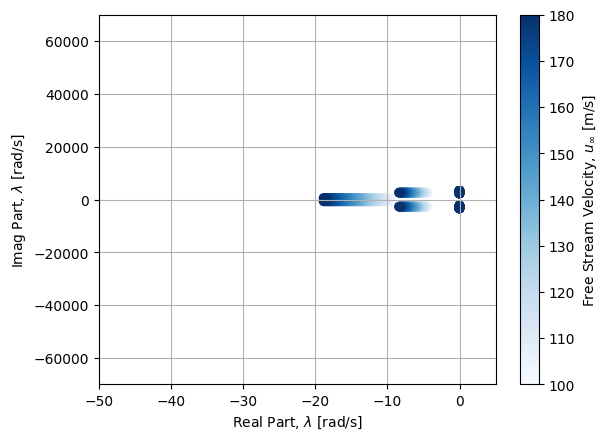

In [ ]:
fig = plt.figure()
print(eigs_r)
print(eigs_i)
plt.scatter(eigs_r, eigs_i, c=u_inf, cmap='Blues')
cbar = plt.colorbar()
cbar.set_label('Free Stream Velocity, $u_\infty$ [m/s]')

plt.grid()
plt.xlim(-50, 5)
plt.ylim(-70000, 70000)
plt.xlabel('Real Part, $\lambda$ [rad/s]')
plt.ylabel('Imag Part, $\lambda$ [rad/s]');

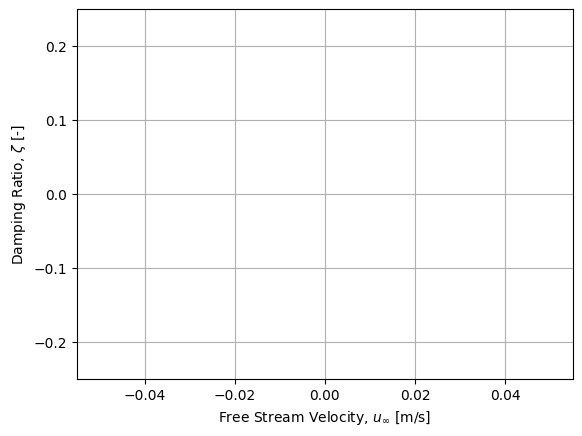

In [ ]:
fig = plt.figure()
natural_frequency = np.sqrt(eigs_r ** 2 + eigs_i ** 2)
damping_ratio = eigs_r / natural_frequency
cond = (eigs_r>-25) * (eigs_r<10) * (natural_frequency<100) # filter unwanted eigenvalues for this plot (mostly aero modes)

plt.scatter(u_inf[cond], damping_ratio[cond], color='k', marker='s', s=9)

plt.grid()
plt.ylim(-0.25, 0.25)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Damping Ratio, $\zeta$ [-]');

[100. 100. 100. 100. 100. 100. 100. 100. 101. 101. 101. 101. 101. 101. 101. 101. 102. 102. 102. 102. 102. 102. 102.
 102. 103. 103. 103. 103. 103. 103. 103. 103. 104. 104. 104. 104. 104. 104. 104. 104. 105. 105. 105. 105. 105. 105.
 105. 105. 106. 106. 106. 106. 106. 106. 106. 106. 107. 107. 107. 107. 107. 107. 107. 107. 108. 108. 108. 108. 108.
 108. 108. 108. 109. 109. 109. 109. 109. 109. 109. 109. 110. 110. 110. 110. 110. 110. 110. 110. 111. 111. 111. 111.
 111. 111. 111. 111. 112. 112. 112. 112. 112. 112. 112. 112. 113. 113. 113. 113. 113. 113. 113. 113. 114. 114. 114.
 114. 114. 114. 114. 114. 115. 115. 115. 115. 115. 115. 115. 115. 116. 116. 116. 116. 116. 116. 116. 116. 117. 117.
 117. 117. 117. 117. 117. 117. 118. 118. 118. 118. 118. 118. 118. 118. 119. 119. 119. 119. 119. 119. 119. 119. 120.
 120. 120. 120. 120. 120. 120. 120. 121. 121. 121. 121. 121. 121. 121. 121. 122. 122. 122. 122. 122. 122. 122. 122.
 123. 123. 123. 123. 123. 123. 123. 123. 124. 124. 124. 124. 124. 124. 1

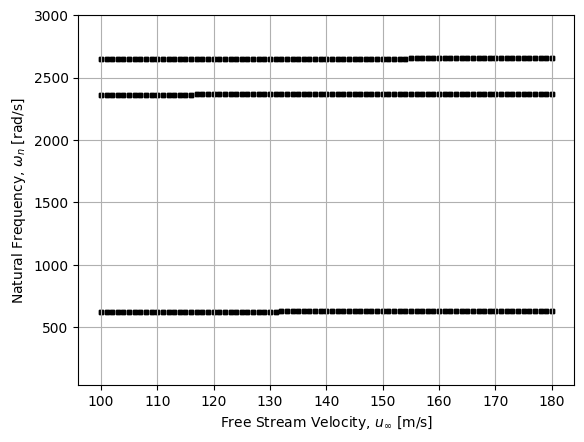

In [ ]:
fig = plt.figure()
cond = (eigs_r>-25) * (eigs_r<10) # filter unwanted eigenvalues for this plot (mostly aero modes)
plt.scatter(u_inf[cond], natural_frequency[cond], color='k', marker='s', s=9)
print(u_inf[cond])
print(natural_frequency[cond])

plt.grid()
plt.ylim(40, 3000)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Natural Frequency, $\omega_n$ [rad/s]');